In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from sim import *
from scipy import stats
import joblib

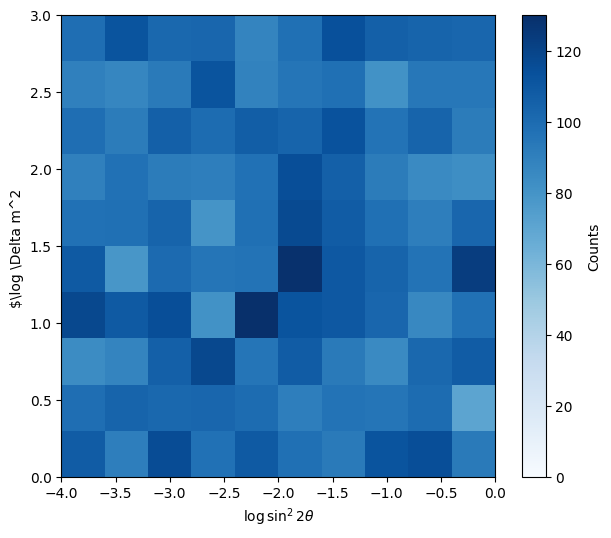

In [2]:
GRIDSIZE = 30
LOG_SIN2_2THETA_BOUNDS = (-4., 0.)
LOG_DELTA_M2_BOUNDS = (0., 3.)
log_sin2_2theta_grid = np.linspace(*LOG_SIN2_2THETA_BOUNDS, GRIDSIZE)
log_delta_m2_grid = np.linspace(*LOG_DELTA_M2_BOUNDS, GRIDSIZE)
THETAS = np.array([[logsinsq, logdmsq] for logsinsq in log_sin2_2theta_grid for logdmsq in log_delta_m2_grid])

def generate_from_uniform_prior(n_samples):
    log_sin2_2theta_samples = np.random.uniform(*LOG_SIN2_2THETA_BOUNDS, n_samples)
    log_delta_m2_samples = np.random.uniform(*LOG_DELTA_M2_BOUNDS, n_samples)
    return np.column_stack((log_sin2_2theta_samples, log_delta_m2_samples))

samples_to_plot = generate_from_uniform_prior(n_samples=10000)
fig, ax = plt.subplots(1, 1, figsize=(7,6), dpi=100)
h = ax.hist2d(samples_to_plot[:, 0], samples_to_plot[:, 1], vmin=0., cmap='Blues')
ax.set_xlim(*LOG_SIN2_2THETA_BOUNDS)
ax.set_ylim(*LOG_DELTA_M2_BOUNDS)
ax.set_xlabel(r'$\log \sin^2 2 \theta$')
ax.set_ylabel(r'$\log \Delta m^2 ')

plt.colorbar(h[3], ax=ax, label='Counts')
plt.show()

In [3]:
# calling on simulator
n_samples = 50000
thetas = generate_from_uniform_prior(n_samples)
theta_ps = generate_from_uniform_prior(n_samples)

xs = []
for theta in tqdm(thetas):
    xs.append(simulate_counts(*(10**theta))[0]) # recall theta is the log of the osc params
xs = np.array(xs)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:18<00:00, 2708.14it/s]


In [5]:
# building labeled data
data1 = np.column_stack((xs, thetas, theta_ps, np.ones(n_samples)))
data0 = np.column_stack((xs, theta_ps, thetas, np.zeros(n_samples)))

data = np.row_stack((data1, data0))

In [21]:
# building training and test-set data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Input, Model, Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

def train_data(data):
    X = data[:, :-1]; y = data[:, -1]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)
    inputs = Input(shape=(X_train.shape[1],))
    link = inputs
    
    for _ in range(5):
        link = layers.Dense(64, activation='relu')(link)

    pre_sigmoid = layers.Dense(1)(link)
    outputs = layers.Activation('sigmoid')(pre_sigmoid)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    
    early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
    )

    history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping]
    )
    pre_sigmoid_model = Model(inputs=model.input, outputs=pre_sigmoid)
    return model, pre_sigmoid_model, scaler

In [ ]:
model, pre_sigmoid = train_data(data)
model.save('models/model.keras')
pre_sigmoid.save('models/pre_sig_model.keras')
joblib.dump(scaler, "models/scaler.joblib")

# Combined Model

In [8]:
n_samples = 50000
thetas = generate_from_uniform_prior(n_samples)
theta_ps = generate_from_uniform_prior(n_samples)

xs = []
for theta in tqdm(thetas):
    xs.append(simulate_counts(*(10**theta))[0])
xs = np.array(xs)

xs2 = []
for theta in tqdm(thetas):
    xs2.append(simulate_counts(*(10**theta))[0])
xs2 = np.array(xs2)

xs_tot = np.c_[xs, xs2]

data1 = np.column_stack((xs_tot, thetas, theta_ps, np.ones(n_samples)))
data0 = np.column_stack((xs_tot, theta_ps, thetas, np.zeros(n_samples)))

data = np.row_stack((data1, data0))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:18<00:00, 2636.11it/s]


In [23]:
model_comb, pre_sigmoid_model_comb,scaler = train_data(data)
model_comb.save('models/model_comb.keras')
pre_sigmoid_model_comb.save('models/pre_sig_model_comb.keras')
joblib.dump(scaler, "models/scaler_comb.joblib")

['../toy/models/scaler_comb.joblib']